# CLIP-Style Zero-Shot Classification on Caltech101
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

Train a CLIP-style zero-shot classifier on Caltech-101, training only the image encoder (vit_small_patch16_224.augreg_in21k_ft_in1k) while keeping the BERT text encoder frozen. After training, we evaluate zero-shot performance on the test split.

In [1]:
!pip install torch torchvision transformers timm tqdm --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import Caltech101
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
import random
from collections import defaultdict
import gc
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
### Updated Step 4: Dataset Loading + Split (No Change to Transform, Just Added Print)
#```python
import os  # Add this to imports if not already there

transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  # Fixes grayscale
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = Caltech101(root='./data', download=True, transform=transform)

# Reproducible split
random.seed(42)
indices_per_class = defaultdict(list)
for idx in range(len(full_dataset)):
    _, label = full_dataset[idx]  # label is int 0-100
    indices_per_class[label].append(idx)

train_indices = []
test_indices = []
for label, idxs in indices_per_class.items():
    random.shuffle(idxs)
    n_train = min(30, len(idxs))
    train_indices.extend(idxs[:n_train])
    test_indices.extend(idxs[n_train:])

trainset = Subset(full_dataset, train_indices)
testset  = Subset(full_dataset, test_indices)

print(f"Train samples: {len(trainset)}")
print(f"Test samples:  {len(testset)}")
print(f"Number of classes: {len(indices_per_class)}")  # 101

batch_size = 128
accumulation_steps = 2

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 137M/137M [00:13<00:00, 10.1MB/s]


Train samples: 3030
Test samples:  5647
Number of classes: 101


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [5]:
# Get the exact category names in the correct label order (sorted as torchvision does)
categories_path = os.path.join('./data', 'caltech101', '101_ObjectCategories')
categories = [d for d in os.listdir(categories_path)
              if os.path.isdir(os.path.join(categories_path, d)) and d != 'BACKGROUND_Google']
categories.sort()  # Critical: matches torchvision's label assignment

# Convert to natural prompt-friendly names (lowercase, underscore → space)
class_names = [name.lower().replace('_', ' ') for name in categories]

print(f"Number of classes: {len(class_names)}")  # Should be 101
print("Example class names:", class_names[:10])   # e.g., ['faces', 'faces easy', 'leopards', ...]

# Templates remain the same
templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

Number of classes: 101
Example class names: ['faces', 'faces easy', 'leopards', 'motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']


In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS]
    return embeddings

text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in class_names]  # Uses dynamic class_names
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (101, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)

# Cleanup
del text_model, tokenizer
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([101, 768])


In [7]:
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0  # Raw features
).to(device)

projection = nn.Linear(384, 768).to(device)
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [8]:
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

scaler = torch.cuda.amp.GradScaler()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

/tmp/ipython-input-2477254637.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
# Updated Training Loop + Per-Epoch Accuracy Monitoring
### New/Updated Step 9.5: Zero-Shot Evaluation Function (Place BEFORE the training loop)

@torch.no_grad()
def zero_shot_accuracy(loader, desc="Test"):
    image_model.eval()
    projection.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast():
            img_feat = image_model(images)
            img_feat = projection(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale.exp() * img_feat @ text_embeddings.T
            preds = logits.argmax(dim=-1)  # Fixed typo here
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    image_model.train()  # Switch back to train mode
    projection.train()
    return 100.0 * correct / total

Epoch 1/20 [Train]:   0%|          | 0/24 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipython-input-117348121.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1 [Train Acc]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3113475244.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - Avg Loss: 4.5194 - Train Acc: 21.52%


Epoch 2/20 [Train]: 100%|██████████| 24/24 [00:12<00:00,  1.99it/s]


Epoch 2/20 - Avg Loss: 4.2695 - Train Acc: 34.92%


Epoch 3/20 [Train]: 100%|██████████| 24/24 [00:11<00:00,  2.05it/s]


...

Epoch 19/20 [Train]: 100%|██████████| 24/24 [00:12<00:00,  1.95it/s]


Epoch 19/20 - Avg Loss: 2.8192 - Train Acc: 92.05%


Epoch 20/20 [Train]: 100%|██████████| 24/24 [00:11<00:00,  2.04it/s]


Epoch 20/20 - Avg Loss: 2.8046 - Train Acc: 92.08%


*** Epoch 20/20 - Test Acc: 80.45% ***


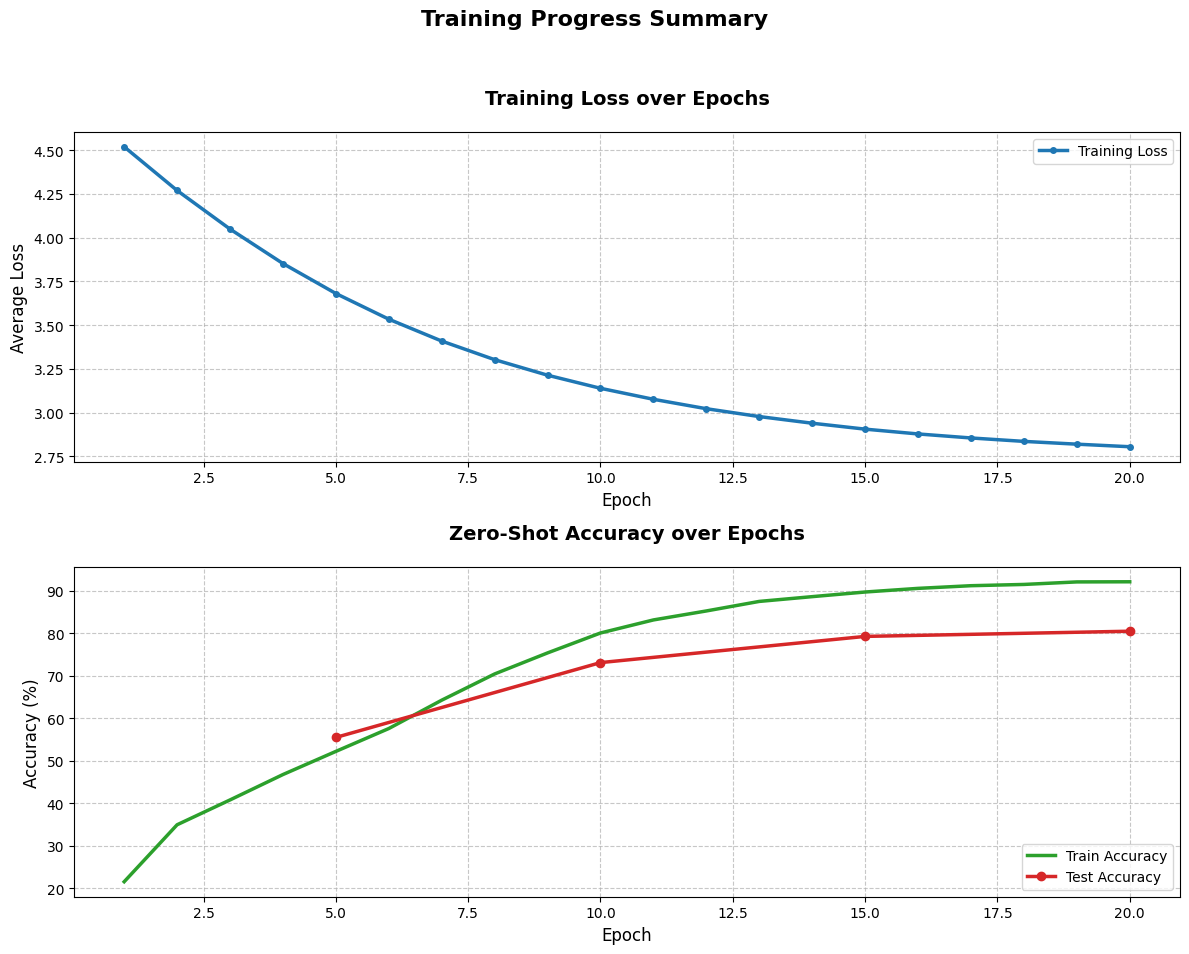

In [10]:
import matplotlib.pyplot as plt  # Add this if not already imported

epochs = 20  # You can increase to 50 later

# Lists to collect metrics for plotting
losses = []
train_accs = []
test_acc_epochs = []
test_accs = []

for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            img_feat = image_model(images)
            img_feat = projection(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale.exp() * img_feat @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

    scheduler.step()
    avg_loss = total_loss / len(trainloader)

    # --- Per-epoch accuracy ---
    train_acc = zero_shot_accuracy(trainloader, desc=f"Epoch {epoch+1} [Train Acc]")

    # Store metrics
    losses.append(avg_loss)
    train_accs.append(train_acc)

    print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f} - Train Acc: {train_acc:.2f}%")

    # Test accuracy every 5 epochs (or at the end)
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        test_acc = zero_shot_accuracy(testloader, desc=f"Epoch {epoch+1} [Test Acc]")
        test_acc_epochs.append(epoch + 1)
        test_accs.append(test_acc)
        print(f"*** Epoch {epoch+1}/{epochs} - Test Acc: {test_acc:.2f}% ***")

    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

# === Professional plotting after training ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# Training Loss
ax1.plot(range(1, epochs + 1), losses, color='tab:blue', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('Training Loss over Epochs', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['Training Loss'], loc='upper right')

# Accuracy (Train + Test)
ax2.plot(range(1, epochs + 1), train_accs, color='tab:green', linewidth=2.5, label='Train Accuracy')
ax2.plot(test_acc_epochs, test_accs, color='tab:red', linewidth=2.5, marker='o', markersize=6, label='Test Accuracy')
ax2.set_title('Zero-Shot Accuracy over Epochs', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Overall figure styling
fig.suptitle('Training Progress Summary', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
# Load DINO pre-trained ViT-small model (self-supervised)
image_model_dino = timm.create_model(
    'vit_small_patch16_224.dino',
    pretrained=True,
    num_classes=0  # Raw features
).to(device)

# Reuse the same projection head and logit scale (reinitialize for fairness)
projection_dino = nn.Linear(384, 768).to(device)
logit_scale_dino = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

# Optimizer for DINO setup
optimizer_dino = torch.optim.AdamW(
    list(image_model_dino.parameters()) + list(projection_dino.parameters()) + [logit_scale_dino],
    lr=5e-5,
    weight_decay=0.01
)

scaler_dino = torch.cuda.amp.GradScaler()
scheduler_dino = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_dino, T_max=30)

model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

/tmp/ipython-input-2777938226.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_dino = torch.cuda.amp.GradScaler()


In [12]:
@torch.no_grad()
def zero_shot_accuracy_dino(loader, desc="Test"):
    image_model_dino.eval()
    projection_dino.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast():
            img_feat = image_model_dino(images)
            img_feat = projection_dino(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale_dino.exp() * img_feat @ text_embeddings.T
            preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    image_model_dino.train()  # Switch back to train mode
    projection_dino.train()
    return 100.0 * correct / total

In [13]:
# Metrics for DINO
losses_dino = []
train_accs_dino = []
test_acc_epochs_dino = []
test_accs_dino = []

for epoch in range(epochs):
    image_model_dino.train()
    projection_dino.train()
    total_loss = 0.0
    optimizer_dino.zero_grad()

    for i, (images, labels) in enumerate(tqdm(trainloader, desc=f"DINO Epoch {epoch+1}/{epochs} [Train]")):
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            img_feat = image_model_dino(images)
            img_feat = projection_dino(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale_dino.exp() * img_feat @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler_dino.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler_dino.step(optimizer_dino)
            scaler_dino.update()
            optimizer_dino.zero_grad()

        total_loss += loss.item() * accumulation_steps

    scheduler_dino.step()
    avg_loss = total_loss / len(trainloader)

    # Per-epoch accuracy
    train_acc = zero_shot_accuracy_dino(trainloader, desc=f"DINO Epoch {epoch+1} [Train Acc]")

    # Store metrics
    losses_dino.append(avg_loss)
    train_accs_dino.append(train_acc)

    print(f"DINO Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f} - Train Acc: {train_acc:.2f}%")

    # Test accuracy every 5 epochs (or at the end)
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        test_acc = zero_shot_accuracy_dino(testloader, desc=f"DINO Epoch {epoch+1} [Test Acc]")
        test_acc_epochs_dino.append(epoch + 1)
        test_accs_dino.append(test_acc)
        print(f"*** DINO Epoch {epoch+1}/{epochs} - Test Acc: {test_acc:.2f}% ***")

    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

DINO Epoch 1/20 [Train]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-1409815100.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
DINO Epoch 1 [Train Acc]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3595958602.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


DINO Epoch 1/20 - Avg Loss: 4.3857 - Train Acc: 29.83%


DINO Epoch 2/20 [Train]: 100%|██████████| 24/24 [00:11<00:00,  2.11it/s]


DINO Epoch 2/20 - Avg Loss: 3.9614 - Train Acc: 46.60%


DINO Epoch 3/20 [Train]: 100%|██████████| 24/24 [00:12<00:00,  1.94it/s]


...

DINO Epoch 19/20 [Train]: 100%|██████████| 24/24 [00:12<00:00,  1.91it/s]


DINO Epoch 19/20 - Avg Loss: 2.6128 - Train Acc: 97.62%


DINO Epoch 20/20 [Train]: 100%|██████████| 24/24 [00:11<00:00,  2.06it/s]


DINO Epoch 20/20 - Avg Loss: 2.6061 - Train Acc: 97.79%


*** DINO Epoch 20/20 - Test Acc: 81.71% ***


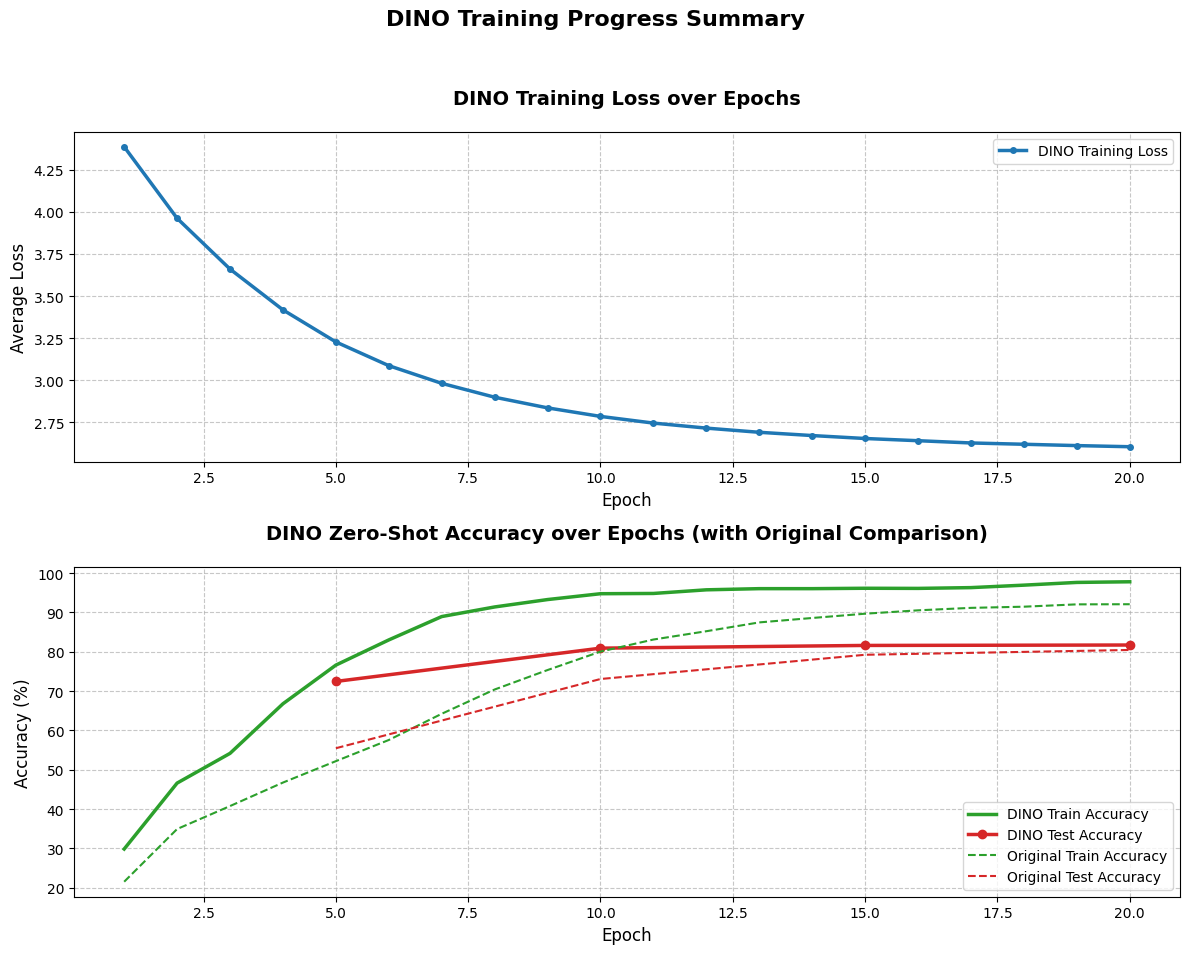

In [14]:
# Plot DINO metrics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# DINO Training Loss
ax1.plot(range(1, epochs + 1), losses_dino, color='tab:blue', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('DINO Training Loss over Epochs', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['DINO Training Loss'], loc='upper right')

# DINO Accuracy (Train + Test)
ax2.plot(range(1, epochs + 1), train_accs_dino, color='tab:green', linewidth=2.5, label='DINO Train Accuracy')
ax2.plot(test_acc_epochs_dino, test_accs_dino, color='tab:red', linewidth=2.5, marker='o', markersize=6, label='DINO Test Accuracy')

# Overlay original for comparison (assuming original metrics are available)
ax2.plot(range(1, epochs + 1), train_accs, color='tab:green', linewidth=1.5, linestyle='--', label='Original Train Accuracy')
ax2.plot(test_acc_epochs, test_accs, color='tab:red', linewidth=1.5, linestyle='--', label='Original Test Accuracy')

ax2.set_title('DINO Zero-Shot Accuracy over Epochs (with Original Comparison)', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Overall figure styling
fig.suptitle('DINO Training Progress Summary', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()